# 05 · High Dimensions and Contamination

Two stress tests that break the assumptions most detectors quietly rely on.

1. **Dimensionality.** As dimension rises, distances *concentrate* — all points drift toward equidistant. Whether that hurts detection turns out to depend on **where the anomaly's signal lives**: extra dimensions that carry signal can help; extra dimensions that are noise hurt badly.
2. **Contamination.** Most detectors assume anomalies are rare. Push the contamination rate up and the detectors that estimate a "normal" region get corrupted by the anomalies they are supposed to exclude.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

_root = Path.cwd()
while _root != _root.parent and not (_root / "pyproject.toml").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.artifacts import save_figure, save_json

plt.rcParams["figure.dpi"] = 110
SEED = 7

from scipy.spatial.distance import pdist
from matplotlib.ticker import ScalarFormatter

from src.datasets.synthetic import make_dataset
from src.detectors import CANONICAL_SIX, make_detector
from src.evaluation.detection import detection_scores
from src.evaluation.comparison import run_dimension_sweep, run_contamination_sweep


def embed_noise(base_X, n_noise, sigma=3.0, seed=0):
    """Append `n_noise` uninformative Gaussian feature columns."""
    rng = np.random.default_rng(seed)
    if n_noise == 0:
        return base_X
    noise = rng.normal(0.0, sigma, size=(base_X.shape[0], n_noise))
    return np.hstack([base_X, noise])


def _nice_log_axis(ax, ticks):
    ax.set_xscale("log")
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.minorticks_off()

## 1 · The fundamental curse: distances concentrate

With purely random points, the gap between the nearest and farthest pair, relative to the nearest, collapses toward zero as dimension grows. By a few hundred dimensions every point is roughly as far from every other — which is exactly the information a distance-based detector relies on.

distance spread ratio: {2: 238.31, 5: 29.87, 10: 4.8, 20: 2.22, 50: 1.07, 100: 0.62, 200: 0.42, 500: 0.28}


PosixPath('/workspaces/outlier_arena/outputs/data/05_distance_concentration.json')

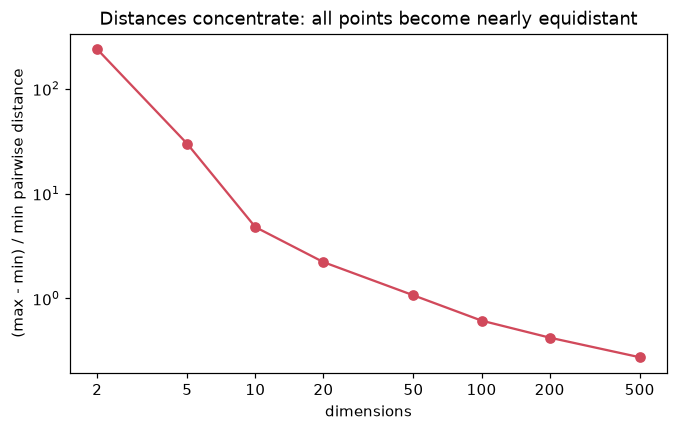

In [2]:
rng = np.random.default_rng(SEED)
dims = [2, 5, 10, 20, 50, 100, 200, 500]
ratios = []
for d in dims:
    Y = rng.random((300, d))
    dd = pdist(Y)
    ratios.append(float((dd.max() - dd.min()) / dd.min()))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dims, ratios, "o-", color="#d1495b")
ax.set(yscale="log", xlabel="dimensions", ylabel="(max - min) / min pairwise distance",
       title="Distances concentrate: all points become nearly equidistant")
_nice_log_axis(ax, dims)
save_figure(fig, "05_distance_concentration")
print("distance spread ratio:", {d: round(r, 2) for d, r in zip(dims, ratios)})
save_json({"dimensions": dims, "distance_spread_ratio": ratios}, "05_distance_concentration")

## 2 · Does dimensionality help or hurt detection?

It depends on the data. **Left:** when every feature carries anomaly signal, more dimensions give distance methods *more* to work with. **Right:** when the signal lives in 2 features and the rest are noise, recall falls for everyone — distance-based detectors (Mahalanobis, LOF, one-class SVM) and Isolation Forest alike, because its random splits keep landing on noise features.

The lesson is not "Isolation Forest always wins" — it is that irrelevant dimensions are poison, so **standardize and reduce dimensionality before distance-based detection**.

PosixPath('/workspaces/outlier_arena/outputs/data/05_dimension_sweep.json')

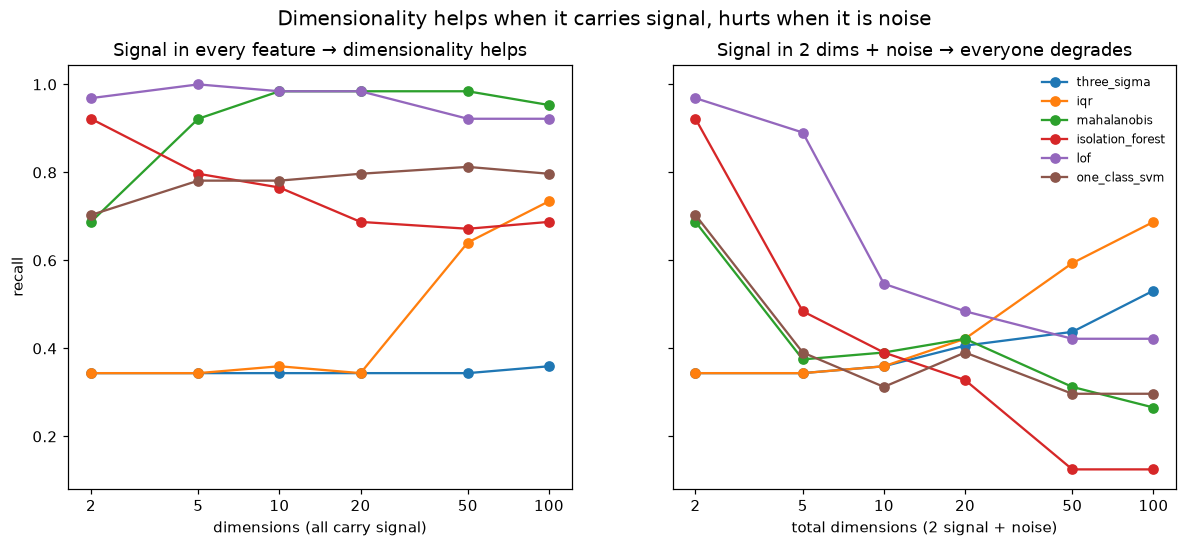

In [3]:
signal_df = run_dimension_sweep([2, 5, 10, 20, 50, 100],
                                n_samples=800, contamination=0.08, seed=SEED)

base = make_dataset(n_samples=800, n_features=2, contamination=0.08, seed=SEED)
noise_dims = [0, 3, 8, 18, 48, 98]
noise_rows = []
for nd in noise_dims:
    Xn = embed_noise(base.X, nd, sigma=3.0, seed=100 + nd)
    for m in CANONICAL_SIX:
        rec = detection_scores(base.y, make_detector(m, 0.08).fit_predict(Xn)).recall
        noise_rows.append({"total_dim": 2 + nd, "detector": m, "recall": rec})
noise_df = pd.DataFrame(noise_rows)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for m in CANONICAL_SIX:
    s = signal_df[signal_df.detector == m]
    axL.plot(s.dimension, s.recall, "o-", label=m)
    n = noise_df[noise_df.detector == m]
    axR.plot(n.total_dim, n.recall, "o-", label=m)
axL.set(xlabel="dimensions (all carry signal)", ylabel="recall",
        title="Signal in every feature → dimensionality helps")
axR.set(xlabel="total dimensions (2 signal + noise)",
        title="Signal in 2 dims + noise → everyone degrades")
_nice_log_axis(axL, [2, 5, 10, 20, 50, 100])
_nice_log_axis(axR, [2 + n for n in noise_dims])
axR.legend(frameon=False, fontsize=8)
fig.suptitle("Dimensionality helps when it carries signal, hurts when it is noise", fontsize=13)
save_figure(fig, "05_dimension_sweep")

save_json({
    "signal_sweep": signal_df.to_dict(orient="records"),
    "noise_sweep": noise_df.to_dict(orient="records"),
}, "05_dimension_sweep")

## 3 · Contamination: when anomalies stop being rare

Each detector is given its intended contamination rate. As the true rate climbs, detectors that model a "normal" region are increasingly corrupted by the anomalies inside it, and recall falls — three-sigma collapses once the outliers are numerous enough to mask one another.

detector        iqr  isolation_forest   lof  mahalanobis  one_class_svm  \
contamination                                                             
0.02           0.38              0.88  1.00         0.88           0.69   
0.05           0.35              0.90  0.98         0.75           0.70   
0.10           0.34              0.91  0.79         0.75           0.70   
0.20           0.34              0.92  0.49         0.69           0.69   
0.35           0.34              0.90  0.33         0.66           0.70   

detector       three_sigma  
contamination               
0.02                  0.38  
0.05                  0.35  
0.10                  0.34  
0.20                  0.32  
0.35                  0.04  


PosixPath('/workspaces/outlier_arena/outputs/data/05_contamination_sweep.json')

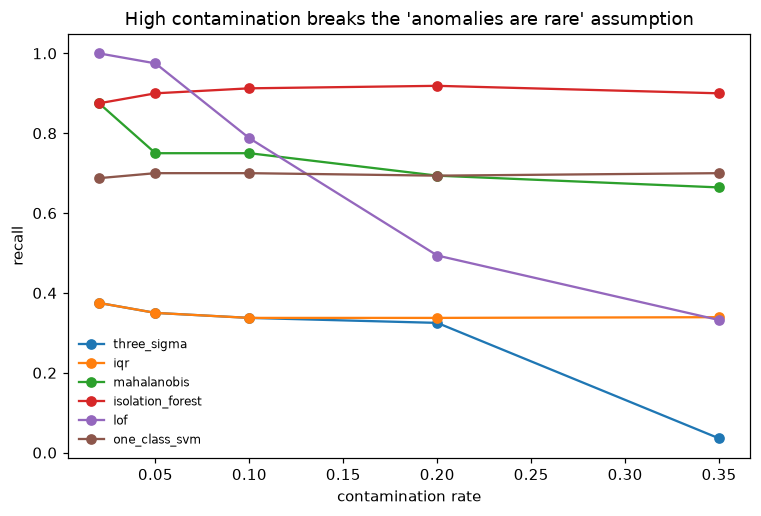

In [4]:
cont_df = run_contamination_sweep([0.02, 0.05, 0.10, 0.20, 0.35],
                                  n_samples=800, n_features=2, seed=SEED)

fig, ax = plt.subplots(figsize=(8, 5))
for m in CANONICAL_SIX:
    s = cont_df[cont_df.detector == m]
    ax.plot(s.contamination, s.recall, "o-", label=m)
ax.set(xlabel="contamination rate", ylabel="recall",
       title="High contamination breaks the 'anomalies are rare' assumption")
ax.legend(frameon=False, fontsize=8)
save_figure(fig, "05_contamination_sweep")
print(cont_df.pivot(index="contamination", columns="detector", values="recall").round(2))
save_json(cont_df.to_dict(orient="records"), "05_contamination_sweep")

## Practical warnings

- **Standardize** before any distance-based detector (Mahalanobis, LOF, one-class SVM).
- **Distrust distance-based detection in high dimensions**, and cut irrelevant features first — noise dimensions dilute every distance.
- **Know your contamination rate.** Most detectors take it as an input and degrade when it is high; above ~20% the "rare anomaly" framing itself breaks down.

In [5]:
summary = {
    "notebook": "05_high_dimensions_and_contamination",
    "distance_concentration": {"dimensions": dims, "ratio": ratios,
                               "ratio_d2": ratios[0], "ratio_d500": ratios[-1]},
    "mahalanobis_recall_2_vs_100_noise_dims": {
        "2": float(noise_df[(noise_df.detector == "mahalanobis") & (noise_df.total_dim == 2)].recall.iloc[0]),
        "100": float(noise_df[(noise_df.detector == "mahalanobis") & (noise_df.total_dim == 100)].recall.iloc[0]),
    },
    "claims": {
        "concentration": "Pairwise distances concentrate as dimension grows (ratio 2D>>500D).",
        "signal_vs_noise": "Extra signal-bearing dims help; extra noise dims hurt all detectors.",
        "contamination": "High contamination corrupts rarity-assuming detectors; three-sigma collapses.",
    },
}
save_json(summary, "05_summary")
summary

{'notebook': '05_high_dimensions_and_contamination',
 'distance_concentration': {'dimensions': [2, 5, 10, 20, 50, 100, 200, 500],
  'ratio': [238.30650334774646,
   29.86978710927869,
   4.7989600522566835,
   2.222626407133873,
   1.0719158092071857,
   0.6150028947981546,
   0.4232753155093414,
   0.27521276545001705],
  'ratio_d2': 238.30650334774646,
  'ratio_d500': 0.27521276545001705},
 'mahalanobis_recall_2_vs_100_noise_dims': {'2': 0.6875, '100': 0.265625},
 'claims': {'concentration': 'Pairwise distances concentrate as dimension grows (ratio 2D>>500D).',
  'signal_vs_noise': 'Extra signal-bearing dims help; extra noise dims hurt all detectors.',
  'contamination': 'High contamination corrupts rarity-assuming detectors; three-sigma collapses.'}}